In [1]:
import pandas as pd
file_path = r'/Users/misbahuddinalif/Downloads/customer_shopping_data (2).csv'
df = pd.read_csv(file_path)
df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon
...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,21/09/2022,Kanyon
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,22/09/2021,Forum Istanbul
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,28/03/2021,Metrocity
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,16/03/2021,Istinye Park


In [2]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [3]:
df.isna().mean()*100

invoice_no        0.0
customer_id       0.0
gender            0.0
age               0.0
category          0.0
quantity          0.0
price             0.0
payment_method    0.0
invoice_date      0.0
shopping_mall     0.0
dtype: float64

In [4]:
df.dtypes

invoice_no            str
customer_id           str
gender                str
age                 int64
category              str
quantity            int64
price             float64
payment_method        str
invoice_date          str
shopping_mall         str
dtype: object

In [5]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], errors='coerce')
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-05-08,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-09-11,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,NaT,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,NaT,Kanyon


In [6]:
df.dtypes

invoice_no                   str
customer_id                  str
gender                       str
age                        int64
category                     str
quantity                   int64
price                    float64
payment_method               str
invoice_date      datetime64[us]
shopping_mall                str
dtype: object

In [7]:
df.isna().mean()*100

invoice_no         0.000000
customer_id        0.000000
gender             0.000000
age                0.000000
category           0.000000
quantity           0.000000
price              0.000000
payment_method     0.000000
invoice_date      59.752456
shopping_mall      0.000000
dtype: float64

In [8]:
df['invoice_date'] = df['invoice_date'].fillna(df['invoice_date'].median())
df.isna().mean()*100

invoice_no        0.0
customer_id       0.0
gender            0.0
age               0.0
category          0.0
quantity          0.0
price             0.0
payment_method    0.0
invoice_date      0.0
shopping_mall     0.0
dtype: float64

In [9]:
df['year'] = df['invoice_date'].dt.year
df['month'] = df['invoice_date'].dt.month
df['day'] = df['invoice_date'].dt.day
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,year,month,day
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-05-08,Kanyon,2022,5,8
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,2021,12,12
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-09-11,Metrocity,2021,9,11
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2022-02-06,Metropol AVM,2022,2,6
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2022-02-06,Kanyon,2022,2,6


In [10]:
df['total_sales'] = df['quantity'] * df['price']
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,year,month,day,total_sales
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-05-08,Kanyon,2022,5,8,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,2021,12,12,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-09-11,Metrocity,2021,9,11,300.08
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2022-02-06,Metropol AVM,2022,2,6,15004.25
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2022-02-06,Kanyon,2022,2,6,242.40


In [11]:
df.dtypes

invoice_no                   str
customer_id                  str
gender                       str
age                        int64
category                     str
quantity                   int64
price                    float64
payment_method               str
invoice_date      datetime64[us]
shopping_mall                str
year                       int32
month                      int32
day                        int32
total_sales              float64
dtype: object

In [12]:
def customer_segment(sales):
    if sales < 5000:
        return 'Budget'
    elif sales <= 15000:
        return 'Regular'
    else:
        return 'Premium'

df['segment'] = df['total_sales'].apply(customer_segment)
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,year,month,day,total_sales,segment
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-05-08,Kanyon,2022,5,8,7502.00,Regular
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,2021,12,12,5401.53,Regular
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-09-11,Metrocity,2021,9,11,300.08,Budget
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2022-02-06,Metropol AVM,2022,2,6,15004.25,Premium
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2022-02-06,Kanyon,2022,2,6,242.40,Budget


In [13]:
df['segment'].value_counts()

segment
Budget     83461
Regular    11981
Premium     4015
Name: count, dtype: int64

In [14]:
def age_group(age):
    if age <= 25:
        return 'Young Adults'
    elif age <= 35:
        return 'Early Professionals'
    elif age <= 45:
        return 'Mid-age Adults'
    elif age <= 55:
        return 'Experienced Adults'
    else:
        return 'Senior Customers'

df['age_group'] = df['age'].apply(age_group)
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,year,month,day,total_sales,segment,age_group
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-05-08,Kanyon,2022,5,8,7502.00,Regular,Early Professionals
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,2021,12,12,5401.53,Regular,Young Adults
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-09-11,Metrocity,2021,9,11,300.08,Budget,Young Adults
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2022-02-06,Metropol AVM,2022,2,6,15004.25,Premium,Senior Customers
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2022-02-06,Kanyon,2022,2,6,242.40,Budget,Experienced Adults


In [15]:
#Most Valuable Customers

df[['customer_id', 'total_sales', 'category', 'age', 'segment', 'age_group']].sort_values(by='total_sales', ascending=False).head(10)

,customer_id,total_sales,category,age,segment,age_group
66026,C115362,26250.0,Technology,28,Premium,Early Professionals
32502,C277412,26250.0,Technology,56,Premium,Senior Customers
50508,C816362,26250.0,Technology,39,Premium,Mid-age Adults
32479,C968145,26250.0,Technology,69,Premium,Senior Customers
96366,C491682,26250.0,Technology,69,Premium,Senior Customers
32423,C333641,26250.0,Technology,64,Premium,Senior Customers
50613,C330627,26250.0,Technology,58,Premium,Senior Customers
9577,C887721,26250.0,Technology,34,Premium,Early Professionals
2402,C922102,26250.0,Technology,44,Premium,Mid-age Adults
915,C252265,26250.0,Technology,66,Premium,Senior Customers


In [18]:
# Month that has the highest sales for the year 2023

df_2023 = df[df['year'] == 2023]
df_2023.groupby('month')[['total_sales']].sum().sort_values(by='total_sales', ascending=False).head(1)

,total_sales
month,
6,1131464.73


In [21]:
# Month in which customers spend the most

monthly_sales = df.groupby('month')[['total_sales']].sum().sort_values(by='total_sales', ascending=False).head(1)
monthly_sales

,total_sales
month,
2,1.588124e+08


In [22]:
# Day in which customers spend the most

daily_sales = df.groupby('day')[['total_sales']].sum().sort_values(by='total_sales', ascending=False).head(1)
daily_sales

,total_sales
day,
6,1.578590e+08


In [23]:
# Segment that has the most customers

df['segment'].value_counts().head(1)

# The highest customer category this business has is budget segment customers. As they are extremely price sensitive, the company should be carefull if they tend to raise any product price. A slight change in price can loose many budget segment customer. This will lower the customer footfall.


segment
Budget    83461
Name: count, dtype: int64

In [24]:
# Segment that generates the most revenue

segment_revenue = df.groupby('segment')[['total_sales']].sum().sort_values(by='total_sales',ascending=False).head(1)
segment_revenue

# Although budget segment customers are the highest in number, but the most revenue generating segment is Regular customer. The business should try to give bundle and promotional offers, discounts and loyalty points to convert Budget customers into Regular customers. This will generate more revenue for the business in the long run. 


,total_sales
segment,
Regular,91872705.14


In [25]:
# The age group of customer that spends more

age_group_sales = df.groupby('age_group')[['total_sales']].sum().sort_values(by='total_sales', ascending=False).head(1)
age_group_sales

# Senior customers are spending more to the business. To retain them, the business can create their preferred environment. Such as creating easy payment options and comfort focus services. 


,total_sales
age_group,
Senior Customers,67103884.89


In [26]:
# Category mostly purchased by Premium customers based on revenue

premium_customers = df[df['segment'] == 'Premium']
premium_customers.groupby('category')[['total_sales']].sum().sort_values(by='total_sales', ascending=False).head(1)

# High value customers are purchasing Technological products, meaning to reach out to them, technology can be the easiest method. The business can promote their products through social media marketing and run digital ads on meta.


,total_sales
category,
Technology,43093050.0


In [27]:
# Top sales category bought by high value customers

premium_customers = df[df['segment'] == 'Premium']
premium_customers['category'].value_counts()

# Although Technological products are the highest revenue generator for high value consumers. But shoes got the highest categorical count. The business can create size exchange or refund terms and condition for specific time so that high value customers keep buying new shoes. Eventually as they are premium customers, they will contribute to Technological sales. 


category
Shoes         2013
Technology    2002
Name: count, dtype: int64

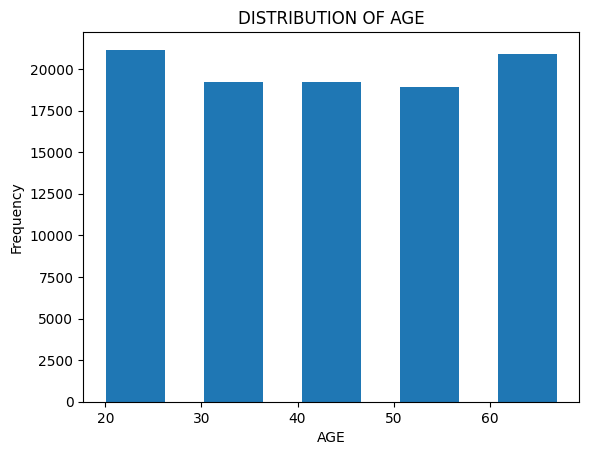

In [28]:
import matplotlib.pyplot as plt

plt.hist(df['age'], bins=5, rwidth=0.6)
plt.xlabel('AGE')
plt.ylabel('Frequency')
plt.title('DISTRIBUTION OF AGE')
plt.show()

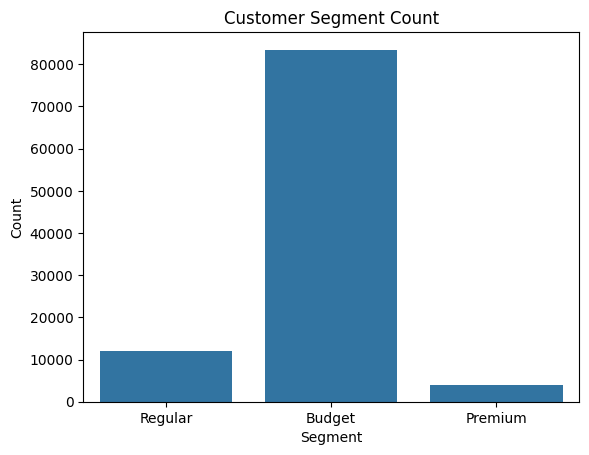

In [30]:
import seaborn as sns

sns.countplot(data=df, x='segment')
plt.xlabel('Segment')
plt.ylabel('Count')
plt.title('Customer Segment Count')
plt.show()